# MAI643 - Deliverable 2 Skeleton (Team 6)

This notebook is structured to match Deliverable 2 requirements.

Workflow:
1. Data understanding
2. EDA
3. Pre-processing
4. Pre-processed dataset versions
5. Selected ML algorithms


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
# TODO: Set dataset path
DATA_PATH = "./data/healthcare-dataset-stroke-data.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset: {DATA_PATH}")
print(f"Shape: {df.shape}")
df.head()


Loaded dataset: ./data/healthcare-dataset-stroke-data.csv
Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Data Understanding

Use this section for report requirement #2:
- shape
- preview
- summary statistics
- class type and class imbalance
- missing values


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
print(df.dtypes)

print("\nNumerical summary:")
display(df.describe(include=[np.number]).T)

print("\nCategorical summary:")
display(df.describe(include=["object", "category", "bool"]).T)


Rows: 5110
Columns: 12

Data types:
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00



Categorical summary:


,count,unique,top,freq
gender,5110,3,Female,2994
ever_married,5110,2,Yes,3353
work_type,5110,5,Private,2925
Residence_type,5110,2,Urban,2596
smoking_status,5110,4,never smoked,1892


In [4]:
# Feature table with inferred type (for report table)
feature_rows = []
for col in df.columns:
    if col == "stroke":
        ftype = "Binary Target"
    elif pd.api.types.is_numeric_dtype(df[col]):
        unique_values = df[col].nunique(dropna=True)
        if unique_values <= 2:
            ftype = "Binary"
        else:
            ftype = "Numerical"
    else:
        ftype = "Categorical"
    feature_rows.append({"feature": col, "dtype": str(df[col].dtype), "type": ftype, "unique_values": df[col].nunique(dropna=True)})

feature_table = pd.DataFrame(feature_rows)
feature_table


,feature,dtype,type,unique_values
0,id,int64,Numerical,5110
1,gender,str,Categorical,3
2,age,float64,Numerical,104
3,hypertension,int64,Binary,2
4,heart_disease,int64,Binary,2
5,ever_married,str,Categorical,2
6,work_type,str,Categorical,5
7,Residence_type,str,Categorical,2
8,avg_glucose_level,float64,Numerical,3979
9,bmi,float64,Numerical,418


In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)
print("\nMissing values table:")
display(missing_table)

target_counts = df["stroke"].value_counts(dropna=False).sort_index()
target_pct = (df["stroke"].value_counts(normalize=True).sort_index() * 100).round(2)
imbalance_table = pd.DataFrame({"count": target_counts, "percent": target_pct})
print("\nTarget distribution:")
display(imbalance_table)


Duplicate rows: 0

Missing values table:


,missing_count,missing_pct
bmi,201,3.93



Target distribution:


,count,percent
stroke,,
0,4861,95.13
1,249,4.87


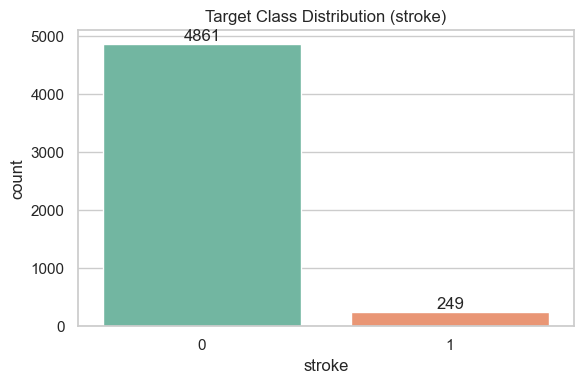

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="stroke", palette="Set2")
ax.set_title("Target Class Distribution (stroke)")
ax.set_xlabel("stroke")
ax.set_ylabel("count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 3. Exploratory Data Analysis (EDA)

Required focus from feedback:
- univariate numerical/categorical analysis
- target vs feature analysis
- correlation and cross-tab relationships


In [7]:
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ["stroke", "id"]]
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


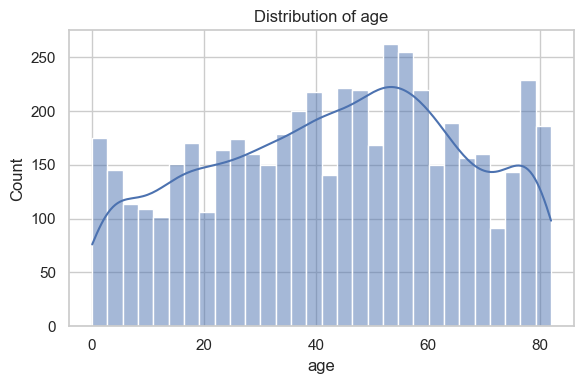

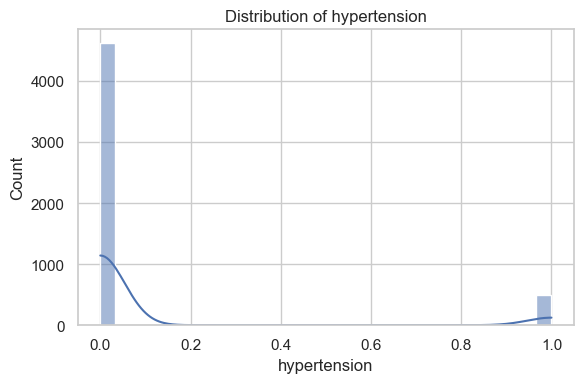

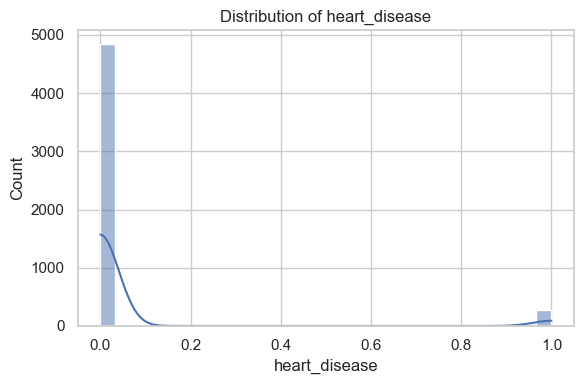

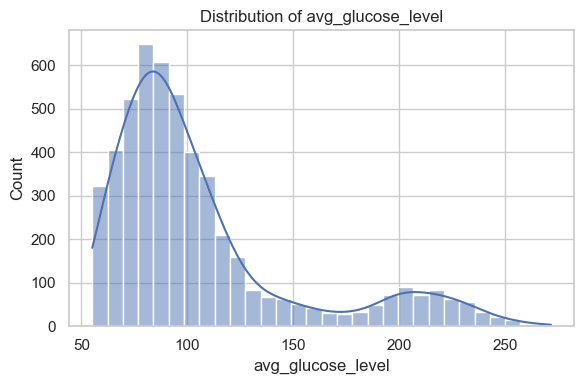

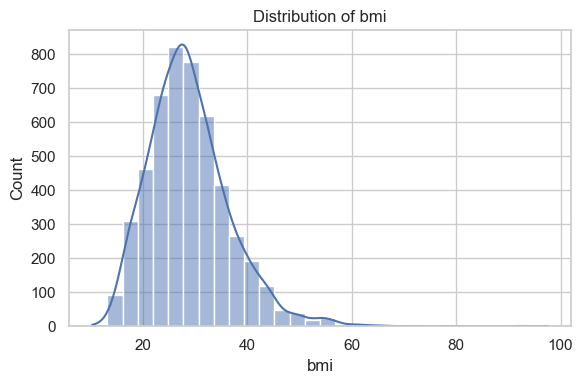

In [8]:
# Histograms for numerical features
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


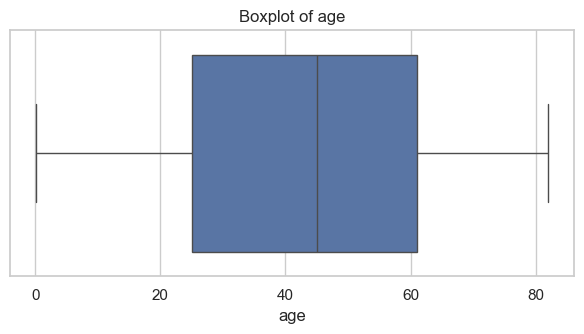

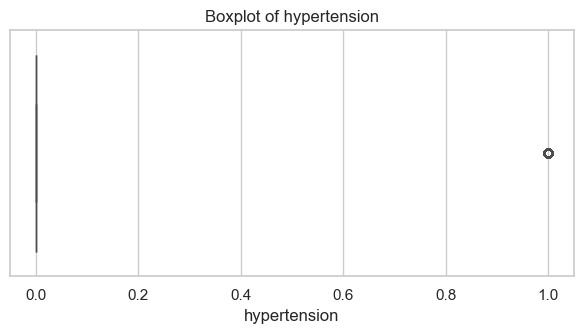

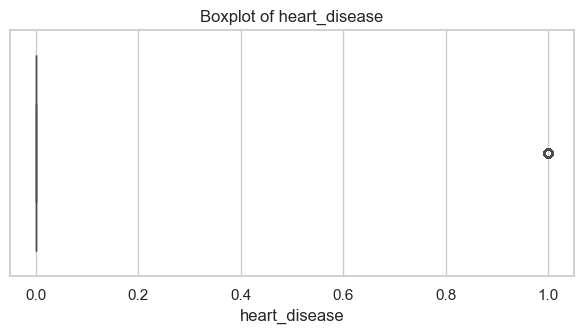

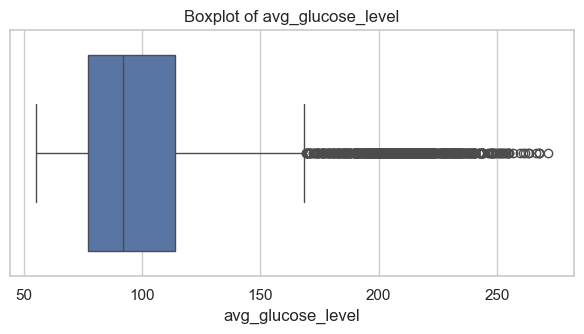

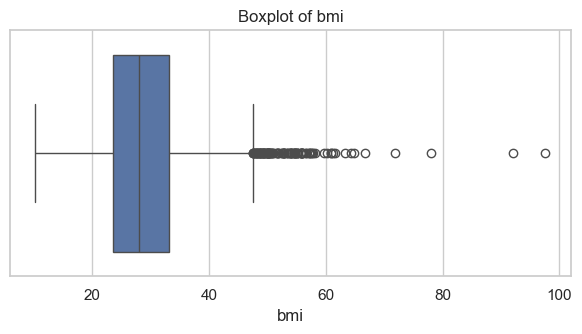

In [9]:
# Boxplots for outlier inspection
for col in num_cols:
    plt.figure(figsize=(6, 3.5))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


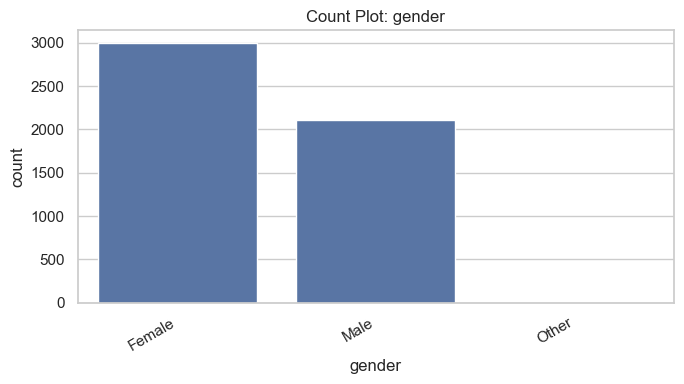

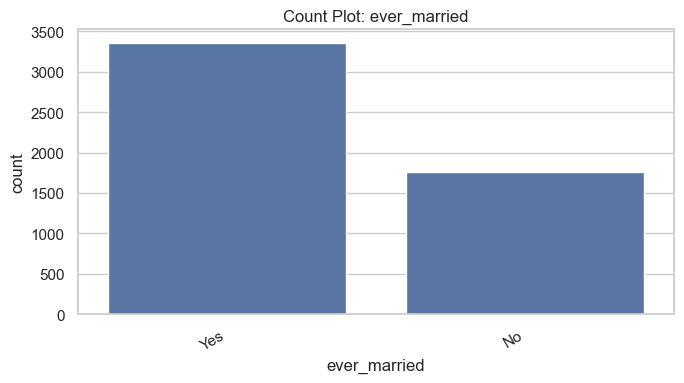

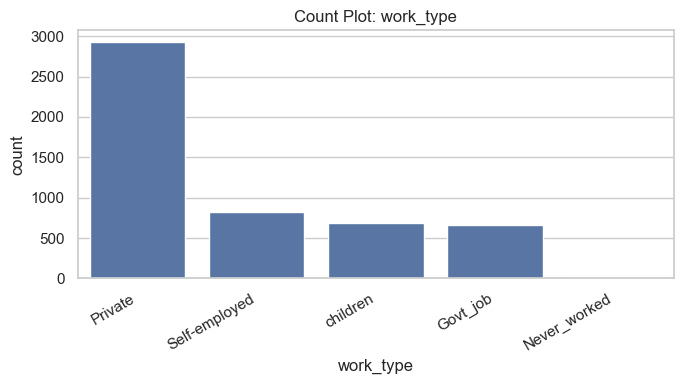

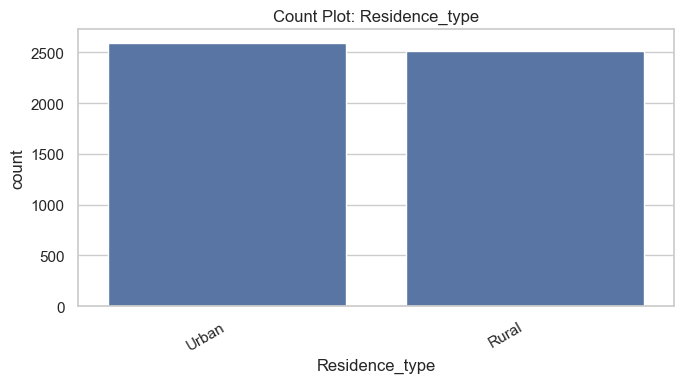

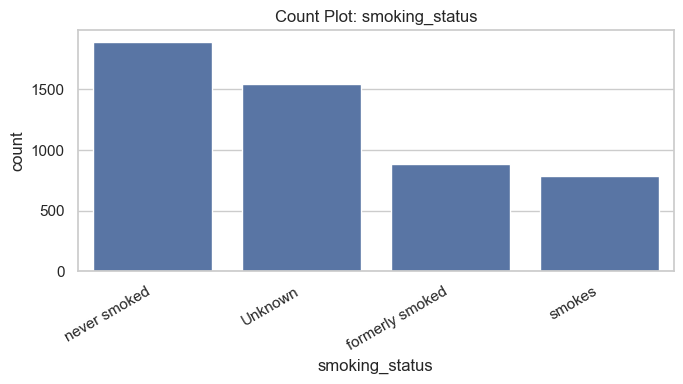

In [10]:
# Countplots for categorical features
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count Plot: {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


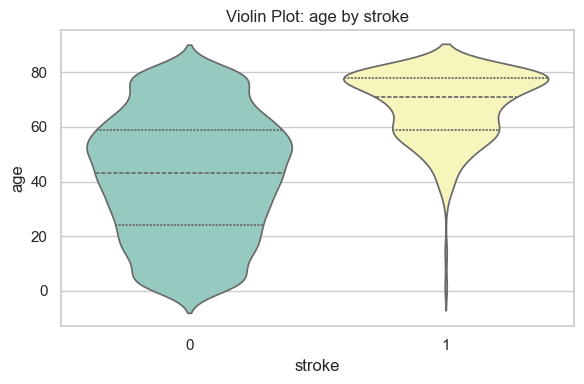

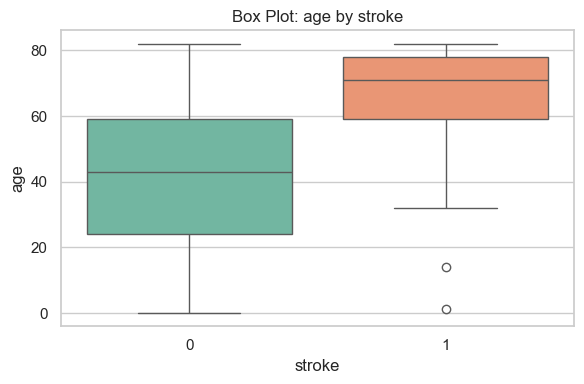

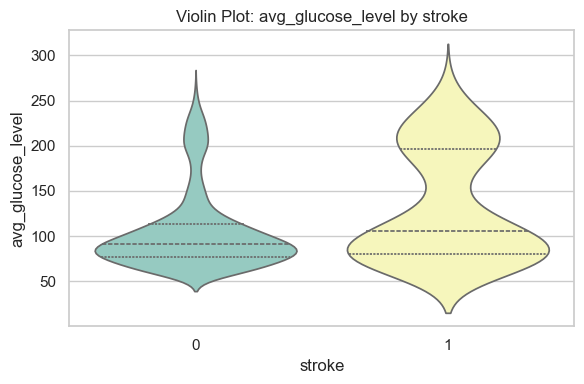

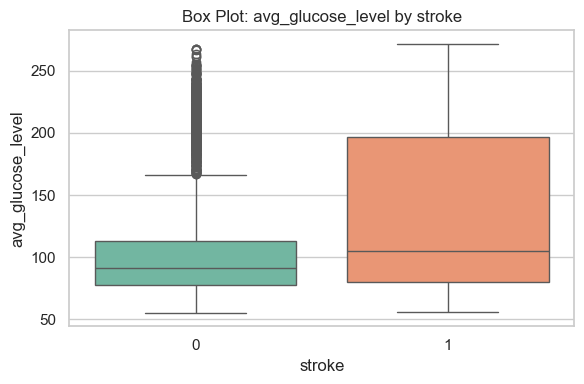

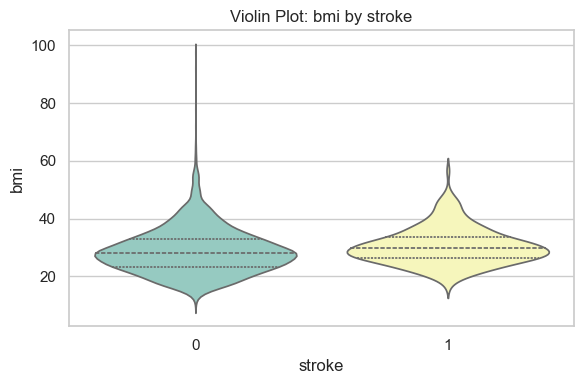

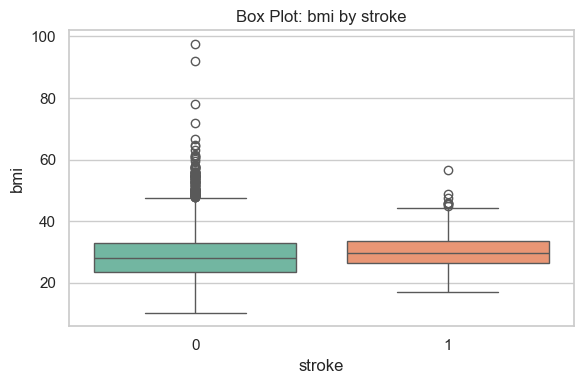

In [11]:
# Numerical features vs target (violin + box)
important_num = [c for c in ["age", "avg_glucose_level", "bmi"] if c in df.columns]

for col in important_num:
    plt.figure(figsize=(6, 4))
    sns.violinplot(data=df, x="stroke", y=col, inner="quartile", palette="Set3")
    plt.title(f"Violin Plot: {col} by stroke")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="stroke", y=col, palette="Set2")
    plt.title(f"Box Plot: {col} by stroke")
    plt.tight_layout()
    plt.show()


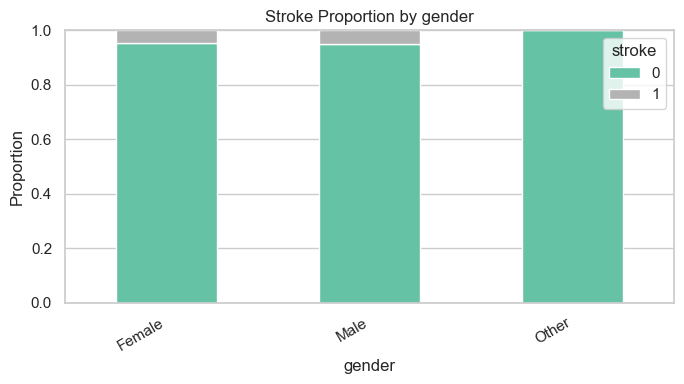

stroke,0,1
gender,,
Female,0.952906,0.047094
Male,0.948936,0.051064
Other,1.000000,0.000000


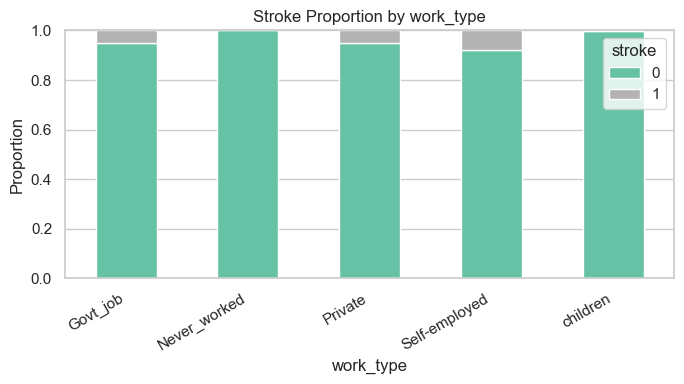

stroke,0,1
work_type,,
Govt_job,0.949772,0.050228
Never_worked,1.000000,0.000000
Private,0.949060,0.050940
Self-employed,0.920635,0.079365
children,0.997089,0.002911


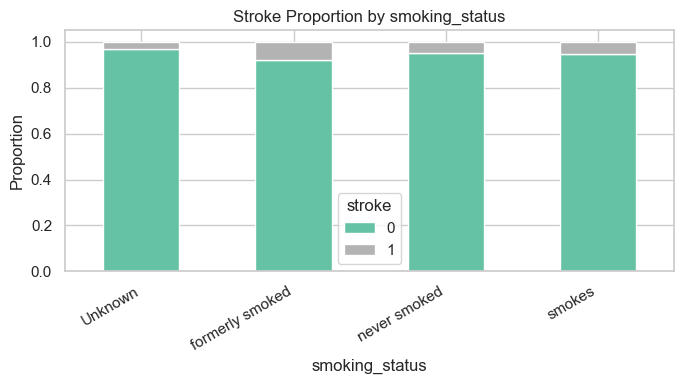

stroke,0,1
smoking_status,,
Unknown,0.969560,0.030440
formerly smoked,0.920904,0.079096
never smoked,0.952431,0.047569
smokes,0.946768,0.053232


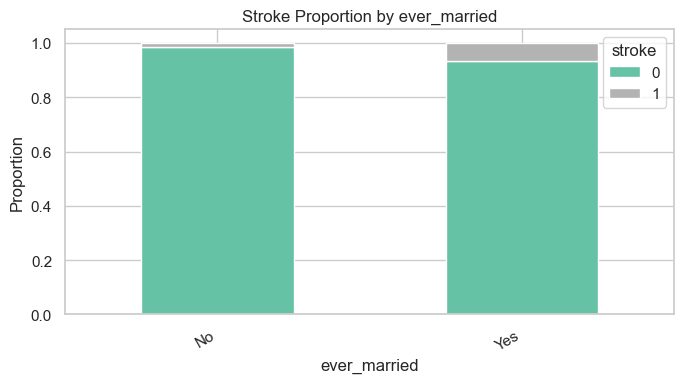

stroke,0,1
ever_married,,
No,0.983495,0.016505
Yes,0.934387,0.065613


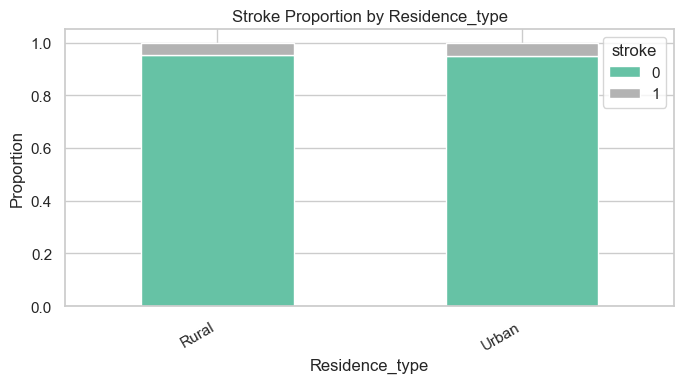

stroke,0,1
Residence_type,,
Rural,0.954654,0.045346
Urban,0.947997,0.052003


In [12]:
# Categorical features vs target (stacked proportion bars)
important_cat = [c for c in ["gender", "work_type", "smoking_status", "ever_married", "Residence_type"] if c in df.columns]

for col in important_cat:
    ctab = pd.crosstab(df[col], df["stroke"], normalize="index")
    ctab.plot(kind="bar", stacked=True, figsize=(7, 4), colormap="Set2")
    plt.title(f"Stroke Proportion by {col}")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="stroke")
    plt.tight_layout()
    plt.show()
    display(ctab)


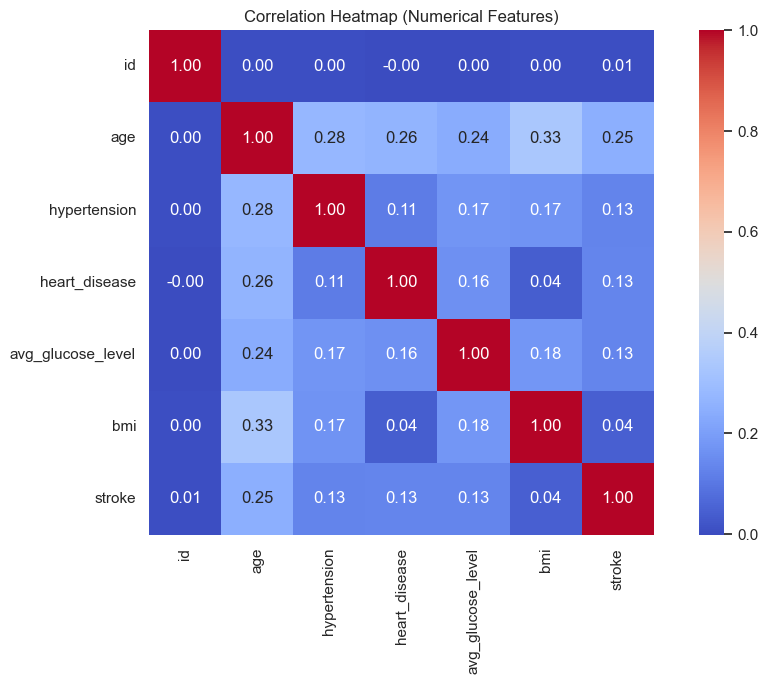

In [13]:
# Correlation heatmap (numerical columns including target)
corr_df = df.select_dtypes(include=[np.number]).copy()
plt.figure(figsize=(10, 7))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()


## 4. Data Pre-processing

Plan based on feedback:
- handle missing values (especially `bmi`)
- encode categorical variables
- scale numerical variables where needed
- address class imbalance (SMOTE)
- optionally test feature extraction (PCA)


In [14]:
# Basic cleaning choices
work_df = df.copy()

# Drop identifier if present
if "id" in work_df.columns:
    work_df = work_df.drop(columns=["id"])

# Drop duplicate rows
before = work_df.shape[0]
work_df = work_df.drop_duplicates()
after = work_df.shape[0]
print(f"Duplicates removed: {before - after}")

X = work_df.drop(columns=["stroke"])
y = work_df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("num_features:", num_features)
print("cat_features:", cat_features)


Duplicates removed: 0
num_features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
cat_features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [15]:
def make_ohe():
    # Compatibility across sklearn versions
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def transform_with_preprocessor(preprocessor, X_tr, X_te):
    Xtr = preprocessor.fit_transform(X_tr)
    Xte = preprocessor.transform(X_te)
    return np.asarray(Xtr), np.asarray(Xte)


# V1: Baseline (Impute + One-Hot)
pre_v1 = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), num_features),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", make_ohe())]), cat_features),
    ],
    remainder="drop"
)
X_train_v1, X_test_v1 = transform_with_preprocessor(pre_v1, X_train, X_test)

# V2: V1 + scaling numerical
pre_v2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_features),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", make_ohe())]), cat_features),
    ],
    remainder="drop"
)
X_train_v2, X_test_v2 = transform_with_preprocessor(pre_v2, X_train, X_test)

# V3: V2 + SMOTE (train only)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_v3, y_train_v3 = smote.fit_resample(X_train_v2, y_train)
X_test_v3, y_test_v3 = X_test_v2, y_test.copy()

# V4: V3 + PCA (retain 95% explained variance)
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_v4 = pca.fit_transform(X_train_v3)
X_test_v4 = pca.transform(X_test_v3)
y_train_v4, y_test_v4 = y_train_v3.copy(), y_test_v3.copy()

print("V1 shapes:", X_train_v1.shape, X_test_v1.shape)
print("V2 shapes:", X_train_v2.shape, X_test_v2.shape)
print("V3 shapes:", X_train_v3.shape, X_test_v3.shape)
print("V4 shapes:", X_train_v4.shape, X_test_v4.shape)
print("PCA components retained:", X_train_v4.shape[1])


V1 shapes: (4088, 21) (1022, 21)
V2 shapes: (4088, 21) (1022, 21)
V3 shapes: (7778, 21) (1022, 21)
V4 shapes: (7778, 11) (1022, 11)
PCA components retained: 11


## 5. Pre-processed Dataset Versions

Use the table below directly in your report (or recreate there).


In [16]:
versions_table = pd.DataFrame([
    {
        "version": "V1",
        "imputation": "median (num), most_frequent (cat)",
        "encoding": "one-hot",
        "scaling": "no",
        "imbalance": "no",
        "feature_reduction": "no",
        "train_shape": X_train_v1.shape,
        "test_shape": X_test_v1.shape,
    },
    {
        "version": "V2",
        "imputation": "median (num), most_frequent (cat)",
        "encoding": "one-hot",
        "scaling": "standard (num)",
        "imbalance": "no",
        "feature_reduction": "no",
        "train_shape": X_train_v2.shape,
        "test_shape": X_test_v2.shape,
    },
    {
        "version": "V3",
        "imputation": "same as V2",
        "encoding": "same as V2",
        "scaling": "same as V2",
        "imbalance": "SMOTE on train",
        "feature_reduction": "no",
        "train_shape": X_train_v3.shape,
        "test_shape": X_test_v3.shape,
    },
    {
        "version": "V4",
        "imputation": "same as V3",
        "encoding": "same as V3",
        "scaling": "same as V3",
        "imbalance": "same as V3",
        "feature_reduction": "PCA (95% variance)",
        "train_shape": X_train_v4.shape,
        "test_shape": X_test_v4.shape,
    },
])

versions_table


,version,imputation,encoding,scaling,imbalance,feature_reduction,train_shape,test_shape
0,V1,"median (num), most_frequent (cat)",one-hot,no,no,no,"(4088, 21)","(1022, 21)"
1,V2,"median (num), most_frequent (cat)",one-hot,standard (num),no,no,"(4088, 21)","(1022, 21)"
2,V3,same as V2,same as V2,same as V2,SMOTE on train,no,"(7778, 21)","(1022, 21)"
3,V4,same as V3,same as V3,same as V3,same as V3,PCA (95% variance),"(7778, 11)","(1022, 11)"


## 6. Selected Machine Learning Algorithms

Deliverable 2 asks for algorithm selection and brief explanation.
This cell defines candidates to be used in Deliverable 3.


In [17]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(random_state=RANDOM_STATE),
}

pd.DataFrame(
    [
        {
            "algorithm": "Logistic Regression",
            "why_relevant": "Interpretable baseline for binary risk prediction.",
        },
        {
            "algorithm": "K-Nearest Neighbors",
            "why_relevant": "Distance-based classifier; useful after scaling.",
        },
        {
            "algorithm": "Random Forest",
            "why_relevant": "Captures nonlinear interactions and handles mixed signals.",
        },
        {
            "algorithm": "Support Vector Machine",
            "why_relevant": "Strong classifier with potentially good class separation.",
        },
    ]
)


,algorithm,why_relevant
0,Logistic Regression,Interpretable baseline for binary risk predict...
1,K-Nearest Neighbors,Distance-based classifier; useful after scaling.
2,Random Forest,Captures nonlinear interactions and handles mi...
3,Support Vector Machine,Strong classifier with potentially good class ...


## 7. Notes for Report Writing

- Under each figure/table, write a 1-3 sentence interpretation.
- Explicitly mention class imbalance percentage and why SMOTE is tested.
- Explain why `id` is removed and how `bmi` missing values are handled.
- Keep this notebook as source code submission; submit report separately as PDF/Word.
